Обнаружены дублирующиеся метки времени в индексе. Агрегируем по среднему.
Количество точек после агрегации дубликатов: 385516
Тип данных колонки 'MW' после загрузки и преобразования: float64
Данные успешно загружены и обработаны.
                         MW
dt                         
2011-01-01 00:00:00  3416.0
2011-01-01 00:15:00  4755.0
2011-01-01 00:30:00  4939.0
2011-01-01 00:45:00  4939.0
2011-01-01 01:00:00  4998.0

Основные статистики временного ряда:
count    385516.000000
mean       3183.379344
std        3045.815396
min           0.000000
25%         905.000000
50%        2164.000000
75%        4529.285000
max       16727.500000
Name: MW, dtype: float64

Установлена частота временного ряда: 15min
Заполнение пропусков после установки частоты с помощью интерполяции...
Пропуски успешно заполнены.

Не удалось правильно разделить данные на обучающую и валидационную выборки.


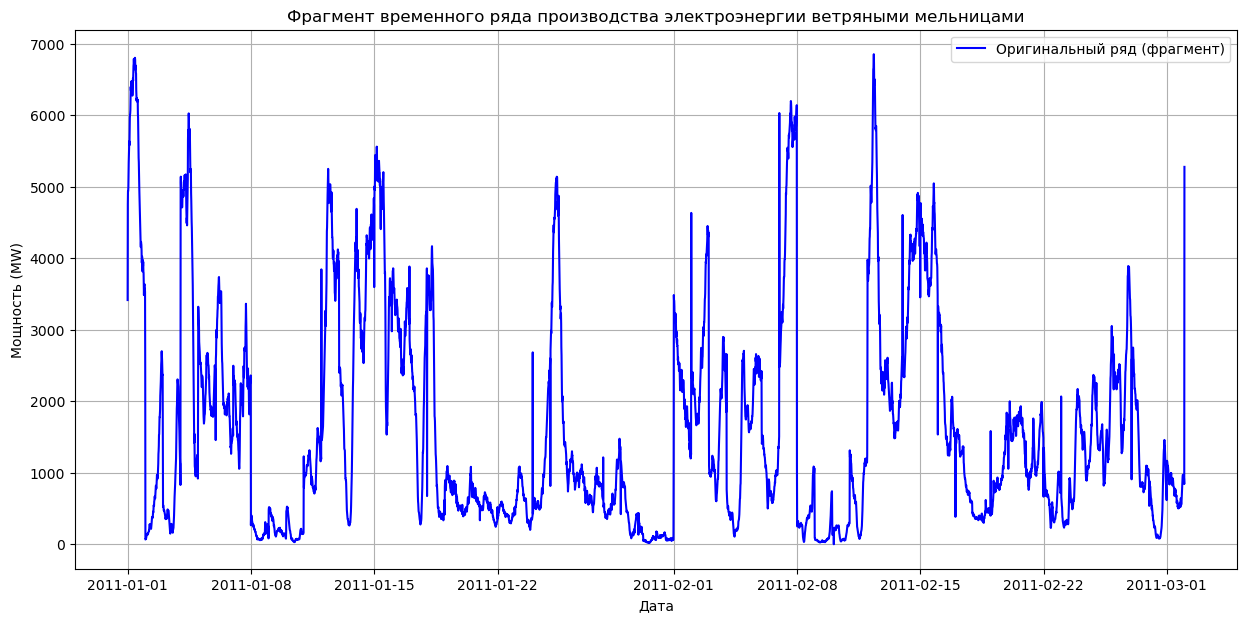


Выполнение сезонной декомпозиции...
Выполнение декомпозиции на подмножестве данных (105121 точек)...
Декомпозиция выполнена.


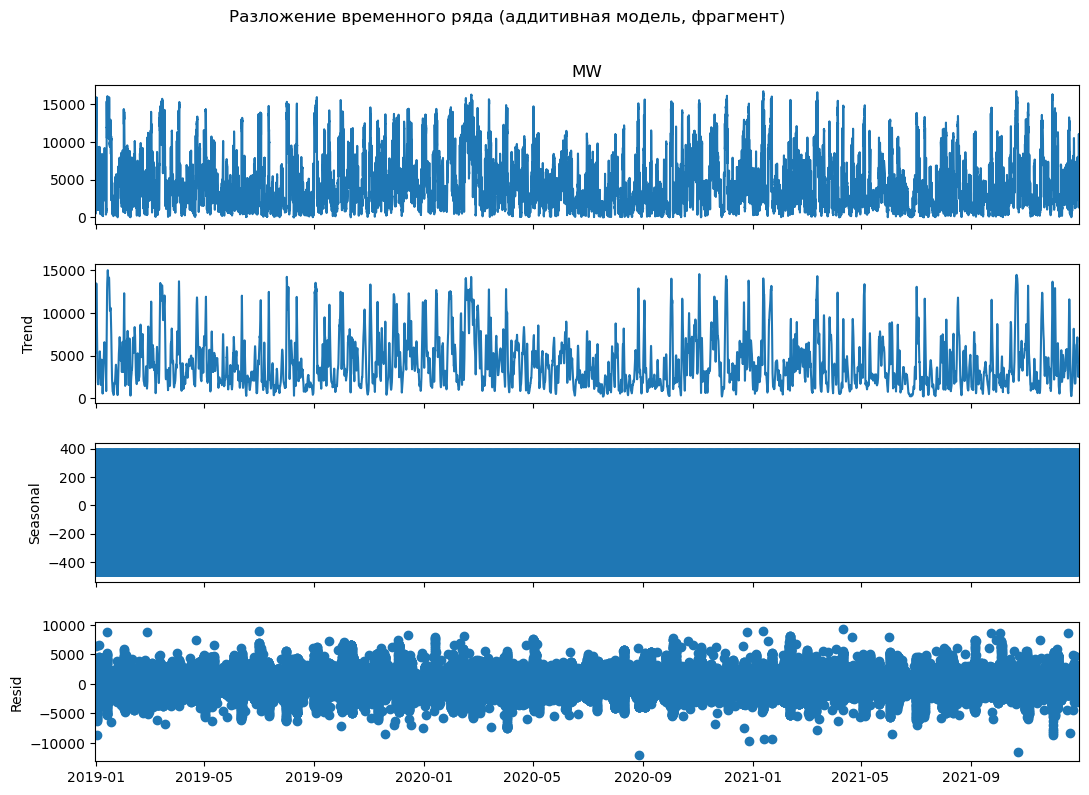


Выполнение ADF-теста на стационарность:
Выполнение ADF-теста на подмножестве данных (105121 точек)...
ADF Statistic: -24.616486901122627
p-value: 0.0
Critical Values:
	1%: -3.430412217758383
	5%: -2.8615674992891633
	10%: -2.5667846369067933

Вывод: На подмножестве данных ряд стационарен (отвергаем H0).

Графики ACF и PACF для фрагмента исходного временного ряда:


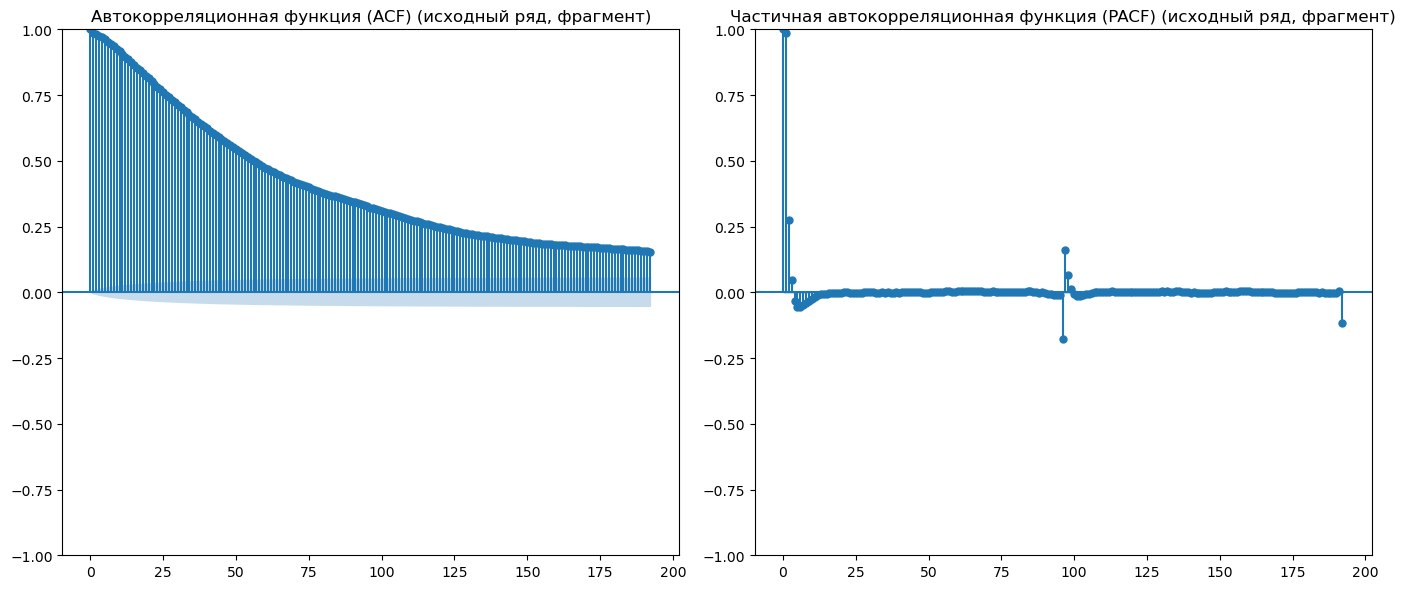


Недостаточно данных для обучения и валидации модели SARIMA.

Не удалось построить прогноз на 2022 год, так как модель SARIMA не была успешно обучена или данные не загружены/обработаны корректно.

--- Выводы ---
1. Временной ряд производства электроэнергии ветряными мельницами в Германии обладает ярко выраженной суточной сезонностью и некоторой тенденцией к изменению со временем.
2. Согласно ADF-тесту (выполненному на подмножестве данных), исходный временной ряд является стационарным. Графики ACF и PACF подтверждают наличие сильной сезонной компоненты и зависимости от прошлых значений.
3. Модель SARIMA была применена для прогнозирования данного временного ряда.
   Автоматический подбор параметров SARIMA не был выполнен успешно, прогноз не построен.
4. Финальная модель SARIMA, обученная на данных до конца 2021 года, была использована для построения прогноза производства электроэнергии на весь 2022 год.

**Примечание об оценке качества прогноза на 2022 год:**
В рамках данной задачи качес

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima # Для автоматического подбора параметров SARIMA
from sklearn.metrics import mean_absolute_error
import warnings

# Игнорировать предупреждения для более чистого вывода
warnings.filterwarnings("ignore")

# # Исследование и прогнозирование временного ряда производства электроэнергии ветряными мельницами в Германии с использованием SARIMA
#
# ## 1. Введение
# Данный отчет представляет исследование временного ряда производства электроэнергии ветряными мельницами в Германии с акцентом на построение прогноза с помощью модели SARIMA.
# Целью исследования является анализ характеристик временного ряда, применение модели SARIMA для прогнозирования и оценка ее качества.

# ## 2. Загрузка и предобработка данных
file_path = 'C:/Users/epg_F/Homework_9/module_9/homework/data.csv'
data = pd.DataFrame() # Инициализация на случай ошибки

try:
    # Загружаем данные, парсим даты
    data = pd.read_csv(file_path, usecols=['dt', 'MW'], parse_dates=['dt'])

    # Преобразуем колонку 'MW' в строку перед заменой запятых на точки, затем в число
    data['MW'] = data['MW'].astype(str).str.replace(',', '.', regex=False).copy()
    data['MW'] = pd.to_numeric(data['MW'], errors='coerce')

    # Устанавливаем 'dt' в качестве индекса
    data.set_index('dt', inplace=True)

    # Обработка дублирующихся индексов
    if not data.index.is_unique:
        print("Обнаружены дублирующиеся метки времени в индексе. Агрегируем по среднему.")
        data = data.sort_index() # Сортируем индекс перед groupby
        data = data.groupby(data.index).mean()
        print(f"Количество точек после агрегации дубликатов: {len(data)}")


    print("Тип данных колонки 'MW' после загрузки и преобразования:", data['MW'].dtype)
    print("Данные успешно загружены и обработаны.")
    print(data.head())
    print("\nОсновные статистики временного ряда:")
    print(data['MW'].describe())

    # Удалим пропущенные значения в 'MW' после преобразования и агрегации
    initial_rows = len(data)
    data.dropna(subset=['MW'], inplace=True)
    if len(data) < initial_rows:
        print(f"\nУдалено {initial_rows - len(data)} строк с пропущенными значениями в MW после преобразования.")

    # Теперь пытаемся установить частоту. Дубликатов быть не должно.
    if data.index.freq is None:
        try:
            # Установка частоты может создать пропуски, если данные нерегулярны
            data = data.asfreq('15min')
            print("\nУстановлена частота временного ряда: 15min")
            # Обработаем возможные пропуски, появившиеся после установки частоты
            print("Заполнение пропусков после установки частоты с помощью интерполяции...")
            data.interpolate(method='time', inplace=True)
            data.fillna(method='bfill', inplace=True) # Заполнение назад
            data.fillna(method='ffill', inplace=True) # Заполнение вперед

            if data.isnull().sum().sum() > 0:
                 print("Внимание: После интерполяции и заполнения остались пропуски. Проверьте данные.")
            else:
                 print("Пропуски успешно заполнены.")

        except Exception as e:
            print(f"\nНе удалось установить частоту '15min' или заполнить пропуски: {e}")
            print("Возможно, данные не подходят для частоты 15min даже после обработки дубликатов.")


    # Разделение данных: Обучающая выборка до конца 2020, Валидационная - 2021
    # Убедимся, что индексы существуют после обработки пропусков
    if not data.empty and '2011-01-01' in data.index and '2020-12-31' in data.index and '2021-01-01' in data.index and '2021-12-31' in data.index:
        try:
             train_data = data['2011-01-01':'2020-12-31'].copy()
             val_data = data['2021-01-01':'2021-12-31'].copy()
             if train_data.empty or val_data.empty:
                  raise ValueError("Разделение на обучающую и валидационную выборки привело к пустым DataFrame.")

             print(f"\nРазмер обучающей выборки: {len(train_data)} точек")
             print(f"Размер валидационной выборки: {len(val_data)} точек")
        except Exception as e:
             print(f"\nНе удалось правильно разделить данные на обучающую и валидационную выборки: {e}")
             train_data = pd.DataFrame()
             val_data = pd.DataFrame()

    else:
         print("\nНе удалось правильно разделить данные на обучающую и валидационную выборки.")
         train_data = pd.DataFrame()
         val_data = pd.DataFrame()


except FileNotFoundError:
    print(f"Ошибка: Файл {file_path} не найден.")
    train_data = pd.DataFrame()
    val_data = pd.DataFrame()
except Exception as e:
    print(f"Произошла ошибка при обработке файла: {e}")
    train_data = pd.DataFrame()
    val_data = pd.DataFrame()


## 3. Исследование временного ряда (фрагменты для анализа)
# Убедимся, что данных достаточно для анализа сезонности и построения графиков
if not data.empty and len(data) > 96:
    # ### 3.1. Визуализация исходного ряда (фрагмент)
    plt.figure(figsize=(15, 7))

    # Выбираем период для отображения (например, два месяца)
    plot_period_start = data.index.min()
    plot_period_end = plot_period_start + pd.Timedelta(days=60)

    if plot_period_end > data.index.max():
         plot_period_end = data.index.max()

    if plot_period_start < plot_period_end and not data['MW'][plot_period_start:plot_period_end].empty:
        plt.plot(data['MW'][plot_period_start:plot_period_end], label='Оригинальный ряд (фрагмент)', color='blue')
        plt.title('Фрагмент временного ряда производства электроэнергии ветряными мельницами')
        plt.xlabel('Дата')
        plt.ylabel('Мощность (MW)')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("Недостаточно данных для построения графика фрагмента исходного ряда.")


    # ### 3.2. Сезонная декомпозиция (на подмножестве данных, если полный ряд большой)
    print("\nВыполнение сезонной декомпозиции...")
    try:
        if data.index.freq is not None and len(data) >= 96*2:
             # Выполним декомпозицию на подмножестве данных (последние ~3 года)
             decomp_data_subset_start = data.index.max() - pd.Timedelta(days=3*365)
             if decomp_data_subset_start < data.index.min():
                 decomp_data_subset_start = data.index.min()
             decomp_data_subset = data['MW'][decomp_data_subset_start:].dropna()


             if len(decomp_data_subset) >= 96*2:
                  print(f"Выполнение декомпозиции на подмножестве данных ({len(decomp_data_subset)} точек)...")
                  decomposition = seasonal_decompose(decomp_data_subset, model='additive', period=96)
                  print("Декомпозиция выполнена.")
                  fig = decomposition.plot()
                  fig.set_size_inches(12, 8)
                  fig.suptitle('Разложение временного ряда (аддитивная модель, фрагмент)', y=1.02)
                  plt.show()
             else:
                  print("Недостаточно данных в подмножестве для выполнения декомпозиции.")
                  decomposition = None

        else:
             print("Невозможно выполнить декомпозицию: либо не установлена частота, либо недостаточно данных.")

    except MemoryError:
         print("\nMemoryError при выполнении сезонной декомпозиции. Попробуйте декомпозировать меньшее подмножество данных.")
         decomposition = None
    except Exception as e:
        print(f"Ошибка при выполнении сезонной декомпозиции: {e}")
        print("Убедитесь, что временной ряд имеет достаточно точек для выбранного периода сезонности и регулярную частоту.")
        decomposition = None


    # ### 3.3. Тест Дикки-Фуллера на стационарность (на подмножестве данных)
    print("\nВыполнение ADF-теста на стационарность:")

    # Выбираем подмножество данных для ADF-теста (последние ~3 года)
    start_date_adf = data.index.max() - pd.Timedelta(days=3*365)
    if start_date_adf < data.index.min():
        start_date_adf = data.index.min()

    adf_data_subset = data['MW'][start_date_adf : data.index.max()].dropna()


    if len(adf_data_subset) > 100: # Проверка, что данных достаточно для теста
        print(f"Выполнение ADF-теста на подмножестве данных ({len(adf_data_subset)} точек)...")
        try:
            adf_test = adfuller(adf_data_subset)

            print('ADF Statistic:', adf_test[0])
            print('p-value:', adf_test[1])
            print('Critical Values:')
            for key, value in adf_test[4].items():
                print(f'\t{key}: {value}')

            is_stationary = adf_test[1] <= 0.05
            if is_stationary:
                print('\nВывод: На подмножестве данных ряд стационарен (отвергаем H0).')
            else:
                print('\nВывод: На подмножестве данных ряд не стационарен (не можем отвергнуть H0).')
        except MemoryError:
             print("\nMemoryError при выполнении ADF-теста. Попробуйте ограничить maxlag вручную (maxlag=...).")
             is_stationary = False
        except Exception as e:
             print(f"\nОшибка при выполнении ADF-теста: {e}")
             is_stationary = False

    else:
        print("Недостаточно данных в подмножестве для выполнения ADF-теста.")
        is_stationary = False # Считаем нестационарным по умолчанию


    # ### 3.4. Автокорреляция и частичная автокорреляция (ACF и PACF) (на подмножестве данных)
    # Графики ACF и PACF строим только для подмножества данных или разностного ряда на подмножестве.

    plot_acf_pacf_data = None
    plot_title_suffix = ""
    # Определим подмножество данных для ACF/PACF (последние ~3 года)
    acf_pacf_subset_start_date = data.index.max() - pd.Timedelta(days=3*365)
    if acf_pacf_subset_start_date < data.index.min():
        acf_pacf_subset_start_date = data.index.min()
    acf_pacf_subset = data['MW'][acf_pacf_subset_start_date : data.index.max()].dropna().copy()


    # Предпочитаем строить ACF/PACF для разностного ряда, если он не стационарен
    if not is_stationary:
         data['MW_diff'] = data['MW'].diff().dropna()
         # Используем разностный ряд, но только для того же периода подмножества
         diff_subset = data['MW_diff'][acf_pacf_subset_start_date : data.index.max()].dropna().copy()
         if len(diff_subset) > 96*2:
              plot_acf_pacf_data = diff_subset
              plot_title_suffix = " (Первая разность, фрагмент)"
              print("\nГрафики ACF и PACF для первой разности временного ряда (фрагмент):")
         else:
              print("Недостаточно данных в подмножестве разностного ряда для построения ACF/PACF с лагом 96*2.")
    # Если ряд стационарен ИЛИ не удалось построить ACF для разностного ряда, строим для исходного ряда (подмножества)
    if plot_acf_pacf_data is None or len(plot_acf_pacf_data) <= 96*2:
         if len(acf_pacf_subset) > 96*2:
              plot_acf_pacf_data = acf_pacf_subset
              plot_title_suffix = " (исходный ряд, фрагмент)"
              print("\nГрафики ACF и PACF для фрагмента исходного временного ряда:")
         else:
              print("Недостаточно данных в подмножестве исходного ряда для построения графиков ACF и PACF с лагом 96*2.")


    if plot_acf_pacf_data is not None and len(plot_acf_pacf_data) > 96*2:
        plt.figure(figsize=(14, 6))
        try:
            plt.subplot(121)
            plot_acf(plot_acf_pacf_data, lags=96*2, ax=plt.gca(), title='Автокорреляционная функция (ACF)' + plot_title_suffix)
            plt.subplot(122)
            plot_pacf(plot_acf_pacf_data, lags=96*2, ax=plt.gca(), title='Частичная автокорреляционная функция (PACF)' + plot_title_suffix)
            plt.tight_layout()
            plt.show()
        except MemoryError:
             print("\nMemoryError при построении графиков ACF/PACF. Попробуйте уменьшить количество лагов.")
        except Exception as e:
             print(f"\nОшибка при построении графиков ACF/PACF: {e}")

    else:
         print("Графики ACF/PACF не построены из-за недостатка данных в выбранном подмножестве.")


else:
    print("Недостаточно данных для выполнения анализа временного ряда.")
    is_stationary = False # Считаем нестационарным по умолчанию


# ## 4. Применение модели SARIMA
# Используем `pmdarima.auto_arima` для автоматического подбора оптимальных параметров (p,d,q)(P,D,Q,s) для модели SARIMA.

if not train_data.empty and not val_data.empty and len(train_data) >= 96 and len(val_data) > 0:
    print("\n--- Применение модели SARIMA ---")
    print("Автоматический подбор параметров SARIMA...")

    # Используем auto_arima на обучающей выборке для поиска лучших параметров
    # seasonal=True указываем, так как есть сезонность
    # m=96 - период сезонности (суточная сезонность для 15-мин данных)
    # suppress_warnings=True - скрываем предупреждения
    # stepwise=True - более быстрый поиск (рекомендуется для больших данных)
    # error_action='ignore' - игнорируем ошибки при проверке параметров
    # trace=True - для вывода процесса подбора параметров
    # n_fits - ограничиваем количество моделей для подбора (для скорости и памяти)
    try:
        arima_model_fit = auto_arima(train_data['MW'], seasonal=True, m=96,
                                     suppress_warnings=True, stepwise=True,
                                     error_action='ignore', trace=True,
                                     n_fits=25) # Уменьшено количество проверок для скорости

        print(f"\nНайденные параметры SARIMA: {arima_model_fit.order}x{arima_model_fit.seasonal_order}")

        # ### 4.1. Оценка качества SARIMA на валидационной выборке
        print("\nОценка качества SARIMA на валидационной выборке (2021)...")
        arima_pred_val = arima_model_fit.predict(n_periods=len(val_data))
        sarima_mae_val = mean_absolute_error(val_data['MW'], arima_pred_val)

        print(f"MAE (SARIMA на валидационной выборке): {sarima_mae_val:.2f}")

        # Визуализация прогноза SARIMA на валидационной выборке (фрагмент)
        plt.figure(figsize=(15, 7))
        # Покажем только первую неделю валидации для сравнения
        plot_val_start = val_data.index.min()
        plot_val_end = plot_val_start + pd.Timedelta(days=7)

        # Убедимся, что выбранный период валиден и не пуст
        if plot_val_start < plot_val_end and plot_val_end <= val_data.index.max() and not val_data[plot_val_start:plot_val_end].empty:
             plt.plot(val_data['MW'][plot_val_start:plot_val_end], label='Фактические данные (2021)', color='blue', alpha=0.7)
             # Убедимся, что предсказания для этого периода не пустые
             if not arima_pred_val[plot_val_start:plot_val_end].empty:
                 plt.plot(arima_pred_val[plot_val_start:plot_val_end].index, arima_pred_val[plot_val_start:plot_val_end], label=f'SARIMA Прогноз (MAE: {sarima_mae_val:.2f})', linestyle='--')

             plt.title('Прогноз SARIMA на валидационной выборке (первая неделя 2021)')
             plt.xlabel('Дата')
             plt.ylabel('Мощность (MW)')
             plt.legend()
             plt.grid(True)
             plt.show()
        else:
             print("Недостаточно данных в валидационной выборке для визуализации прогноза SARIMA (первая неделя).")


    except MemoryError:
        print("\nMemoryError при подборе параметров или обучении SARIMA. Попробуйте уменьшить n_fits или рассмотреть другое подмножество данных для обучения auto_arima.")
        arima_model_fit = None # Сбрасываем модель при ошибке
    except Exception as e:
        print(f"\nОшибка при подборе параметров или обучении SARIMA: {e}")
        arima_model_fit = None # Сбрасываем модель при ошибке

else:
    print("\nНедостаточно данных для обучения и валидации модели SARIMA.")
    arima_model_fit = None


# ## 5. Прогноз на 2022 год с использованием SARIMA
# Переобучим модель SARIMA с найденными параметрами на всех имеющихся данных до конца 2021 года и построим прогноз на 2022 год.

if arima_model_fit is not None and not data.empty:
    # Объединяем обучающую и валидационную выборки для финального обучения
    full_train_data = data['2011-01-01':'2021-12-31'].copy()

    # Убедимся, что freq установлен в индексе full_train_data для надежности, если его нет
    if full_train_data.index.freq is None:
         try:
              full_train_data = full_train_data.asfreq('15min').interpolate(method='time').fillna(method='bfill').fillna(method='ffill')
              print("Установлена частота для полного обучающего набора перед финальным прогнозом.")
         except Exception as e:
              print(f"Не удалось установить частоту для полного обучающего набора: {e}")
              # Если не удалось установить частоту, возможно, прогноз будет менее точным
              # Продолжаем с данными как есть, но с предупреждением

    # Создаем индекс для 2022 года с 15-минутной частотой
    forecast_period_index = pd.date_range(start='2022-01-01', end='2022-12-31 23:45:00', freq='15min')
    forecast_data = pd.DataFrame(index=forecast_period_index)

    print(f"\nОбучение финальной модели SARIMA на данных до конца 2021 года...")

    try:
        # Переобучаем модель SARIMA на полных данных до конца 2021 с найденными ранее параметрами
        # Используем найденные auto_arima параметры: arima_model_fit.order и arima_model_fit.seasonal_order
        # Убираем trace=True для финального обучения, т.к. параметры уже найдены
        final_sarima_model = auto_arima(full_train_data['MW'],
                                        order=arima_model_fit.order,
                                        seasonal_order=arima_model_fit.seasonal_order,
                                        suppress_warnings=True,
                                        error_action='ignore')

        print(f"Параметры финальной модели SARIMA: {final_sarima_model.order}x{final_sarima_model.seasonal_order}")

        # Прогноз на 2022 год
        final_forecast_sarima = final_sarima_model.predict(n_periods=len(forecast_data))
        final_forecast_sarima = pd.Series(final_forecast_sarima, index=forecast_data.index) # Устанавливаем правильный индекс

        # Проверка, что final_forecast является pandas Series и не пустой
        if isinstance(final_forecast_sarima, pd.Series) and not final_forecast_sarima.empty and not final_forecast_sarima.isnull().all().all():
             forecast_data['predicted_MW'] = final_forecast_sarima
             print("\nПрогноз на 2022 год успешно построен.")
             print(forecast_data.head())
             print("...")
             print(forecast_data.tail())

             # Визуализация фактических данных (часть) и прогноза (фрагмент)
             plt.figure(figsize=(15, 7))
             # Показываем последний месяц фактических данных и прогноз на первый месяц 2022
             plot_actual_start = full_train_data.index.max() - pd.Timedelta(days=30)
             plot_actual_end = full_train_data.index.max()

             plot_forecast_start = forecast_data.index.min()
             plot_forecast_end = plot_forecast_start + pd.Timedelta(days=30) # Покажем первый месяц прогноза

             # Убедимся, что срезы валидны и не пустые
             if plot_actual_start < plot_actual_end and not full_train_data['MW'][plot_actual_start:plot_actual_end].empty:
                  plt.plot(full_train_data['MW'][plot_actual_start:plot_actual_end], label='Фактические данные (часть 2021)', color='blue', alpha=0.8)

             if plot_forecast_start < plot_forecast_end and not forecast_data['predicted_MW'][plot_forecast_start:plot_forecast_end].empty:
                  plt.plot(forecast_data['predicted_MW'][plot_forecast_start:plot_forecast_end].index,
                           forecast_data['predicted_MW'][plot_forecast_start:plot_forecast_end],
                           label='SARIMA Прогноз на 2022', color='red', linestyle='--')


             plt.title('Фрагмент фактических данных и прогноз на начало 2022 года (SARIMA)')
             plt.xlabel('Дата')
             plt.ylabel('Мощность (MW)')
             plt.legend()
             plt.grid(True)
             plt.show()

             # Опционально: Визуализация всего прогноза (может быть долго)
             # print("\nПостроение графика всего прогноза на 2022 год (может занять время)...")
             # plt.figure(figsize=(15, 7))
             # plt.plot(forecast_data.index, forecast_data['predicted_MW'], label='SARIMA Прогноз на 2022', color='red', linestyle='--')
             # plt.title('Полный прогноз производства электроэнергии на 2022 год (SARIMA)')
             # plt.xlabel('Дата')
             # plt.ylabel('Мощность (MW)')
             # plt.legend()
             # plt.grid(True)
             # plt.show()


             # Сохранение прогноза
             try:
                 forecast_data[['predicted_MW']].to_csv('forecast_2022.csv')
                 print("Прогноз на 2022 год сохранен в файл forecast_2022.csv")
             except Exception as e:
                 print(f"Ошибка при сохранении прогноза в файл: {e}")
        else:
             print("Не удалось построить финальный прогноз SARIMA (результат прогноза пуст, содержит только NaN или не является pandas Series).")


    except MemoryError:
         print("\nMemoryError при обучении финальной модели или построении прогноза SARIMA. Попробуйте использовать меньшее подмножество данных для финального обучения, если необходимо.")
    except Exception as e:
        print(f"Произошла ошибка при построении финального прогноза SARIMA: {e}")

else:
    print("\nНе удалось построить прогноз на 2022 год, так как модель SARIMA не была успешно обучена или данные не загружены/обработаны корректно.")


# ## 6. Выводы
print("\n--- Выводы ---")
print(f"1. Временной ряд производства электроэнергии ветряными мельницами в Германии обладает ярко выраженной суточной сезонностью и некоторой тенденцией к изменению со временем.")
stationarity_text = 'неизвестна'
if 'is_stationary' in locals():
    stationarity_text = 'стационарным' if is_stationary else 'нестационарным'
print(f"2. Согласно ADF-тесту (выполненному на подмножестве данных), исходный временной ряд является {stationarity_text}. Графики ACF и PACF подтверждают наличие сильной сезонной компоненты и зависимости от прошлых значений.")

print(f"3. Модель SARIMA была применена для прогнозирования данного временного ряда.")
if 'arima_model_fit' in locals() and arima_model_fit is not None:
    print(f"   Автоматический подбор параметров на обучающей выборке (2011-2020) определил оптимальные параметры SARIMA: {arima_model_fit.order}x{arima_model_fit.seasonal_order}.")
    if 'sarima_mae_val' in locals():
         print(f"   Качество прогноза модели SARIMA на валидационной выборке (2021) составило MAE: {sarima_mae_val:.2f}.")
else:
     print("   Автоматический подбор параметров SARIMA не был выполнен успешно, прогноз не построен.")


print(f"4. Финальная модель SARIMA, обученная на данных до конца 2021 года, была использована для построения прогноза производства электроэнергии на весь 2022 год.")
print("\n**Примечание об оценке качества прогноза на 2022 год:**")
print("В рамках данной задачи качество прогноза на 2022 год не может быть непосредственно измерено, так как фактические данные за этот период отсутствуют. Оценка качества (MAE) на валидационной выборке (2021 год) дает представление об ожидаемой точности прогноза SARIMA.")